<a href="https://colab.research.google.com/github/johrosa/srwi/blob/main/plant_phenology_multisite_pixel_sampling_colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant phenology monitoring — multiple GeoPackage points

Google Colab workflow using **Sentinel-2 + ERA5-Land**.

The notebook:
- imports a `.gpkg` point layer;
- processes every point independently;
- extracts NDVI/EVI2/NDMI time series;
- derives SOS, Peak and EOS by site and phenological year;
- extracts ERA5-Land climate by site;
- identifies heat, heavy-rain and dry anomalies;
- compares phenology and climate;
- exports site-level CSV tables.


In [1]:
!pip -q install earthengine-api geemap geopandas pyogrio scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.0 MB/s eta 0:00:00


In [2]:
import ee, geemap
import geopandas as gpd
import pyogrio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from google.colab import files
from IPython.display import display

## 1. Parameters

In [3]:
PROJECT_ID = "ee-rnrimpact"

SITE_ID_FIELD = "id"
GPKG_LAYER = "manga"

START_DATE = "2018-01-01"
END_DATE = "2025-12-31"

CLIM_BASELINE_START = "2000-01-01"
CLIM_BASELINE_END = "2024-12-31"

PHENO_YEAR_START_MONTH = 7

COMPOSITE_DAYS = 10
CLEAR_THRESHOLD = 0.60
S2_SCALE_M = 20

PHENO_THRESHOLD_FRACTION = 0.20
SMOOTH_WINDOW = 7
SMOOTH_POLYORDER = 2

HEAT_PERCENTILE = 95
HEAVY_RAIN_PERCENTILE = 95
ROLLING_RAIN_DAYS = 30
DRY_Z_THRESHOLD = -1.5

ERA5_SCALE_M = 11132

## 2. Earth Engine authentication

In [4]:
ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print("Earth Engine initialized")

/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


Earth Engine initialized


## 3. Upload GeoPackage

In [5]:
uploaded = files.upload()

gpkg_files = [f for f in uploaded if f.lower().endswith(".gpkg")]
if not gpkg_files:
    raise ValueError("Upload a .gpkg file")

GPKG_FILE = gpkg_files[0]
layers = pyogrio.list_layers(GPKG_FILE)

print("GeoPackage:", GPKG_FILE)
display(pd.DataFrame(layers, columns=["layer", "geometry_type"]))

Saving srwi_maroa_manga.gpkg to srwi_maroa_manga.gpkg
GeoPackage: srwi_maroa_manga.gpkg


/usr/local/lib/python3.13/dist-packages/pyogrio/core.py:169: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'srwi_maroa_manga.gpkg'
  return ogr_list_layers(get_vsi_path_or_buffer(path_or_buffer))


,layer,geometry_type
0,manga,Point Z
1,hafa,Point Z
2,android_metadata,None


In [6]:
if GPKG_LAYER is None:
    GPKG_LAYER = layers[0][0]

gdf = gpd.read_file(GPKG_FILE, layer=GPKG_LAYER)

if gdf.crs is None:
    raise ValueError("GeoPackage layer has no CRS")

gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
gdf = gdf.explode(index_parts=False, ignore_index=True)

if not set(gdf.geometry.geom_type).issubset({"Point"}):
    raise ValueError("The selected layer must contain Point/MultiPoint geometries only")

gdf = gdf.to_crs("EPSG:4326")

if SITE_ID_FIELD in gdf.columns:
    gdf["site_id"] = gdf[SITE_ID_FIELD].astype(str)
else:
    gdf["site_id"] = [f"P{i+1:03d}" for i in range(len(gdf))]

if gdf["site_id"].duplicated().any():
    gdf["site_id"] = gdf["site_id"] + "_" + (gdf.groupby("site_id").cumcount()+1).astype(str)

gdf["longitude"] = gdf.geometry.x
gdf["latitude"] = gdf.geometry.y

print("Layer:", GPKG_LAYER)
print("Sites:", len(gdf))
display(gdf[["site_id","longitude","latitude"]].head(20))

/usr/local/lib/python3.13/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on 'srwi_maroa_manga.gpkg'
  return ogr_read(


Layer: manga
Sites: 88


,site_id,longitude,latitude
0,P001,49.739936,-15.432280
1,P002,49.739400,-15.433495
2,P003,49.739344,-15.437249
3,P004,49.740075,-15.438904
4,P005,49.741073,-15.438988
5,P006,49.741512,-15.438355
6,P007,49.743984,-15.438027
7,P008,49.744509,-15.436671
8,P009,49.745509,-15.437090
9,P010,49.744413,-15.435506


## 4. Convert sites to Earth Engine

In [7]:
features = []
for _, r in gdf.iterrows():
    features.append(
        ee.Feature(
            ee.Geometry.Point([float(r.longitude), float(r.latitude)]),
            {
                "site_id": str(r.site_id),
                "longitude": float(r.longitude),
                "latitude": float(r.latitude)
            }
        )
    )

sites = ee.FeatureCollection(features)
study_geometry = sites.geometry().bounds().buffer(1000)

print("EE sites:", sites.size().getInfo())

Map = geemap.Map()
Map.centerObject(sites, 7)
Map.addLayer(sites, {"color":"red"}, "Sites")
Map

/usr/local/lib/python3.13/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


EE sites: 88


Map(center=[-15.959683004695986, 49.6793903935925], controls=(WidgetControl(options=['position', 'transparent_…

## 5. Sentinel-2 preprocessing

**Lightweight mode:** Sentinel‑2 values are sampled from the single pixel intersecting each point. No buffer and no neighborhood median are calculated.

In [8]:
S2_ID = "COPERNICUS/S2_SR_HARMONIZED"
CS_ID = "GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED"

s2 = (ee.ImageCollection(S2_ID)
      .filterBounds(study_geometry)
      .filterDate(START_DATE, ee.Date(END_DATE).advance(1,"day")))

cs = (ee.ImageCollection(CS_ID)
      .filterBounds(study_geometry)
      .filterDate(START_DATE, ee.Date(END_DATE).advance(1,"day")))

s2_linked = s2.linkCollection(cs, ["cs_cdf"])

def prep_s2(img):
    clear = img.select("cs_cdf").gte(CLEAR_THRESHOLD)
    x = img.select(["B4","B8","B11"]).multiply(0.0001)

    red = x.select("B4")
    nir = x.select("B8")
    swir = x.select("B11")

    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    evi2 = nir.subtract(red).multiply(2.5).divide(
        nir.add(red.multiply(2.4)).add(1)
    ).rename("EVI2")
    ndmi = nir.subtract(swir).divide(nir.add(swir)).rename("NDMI")

    return ee.Image.cat([ndvi,evi2,ndmi]).updateMask(clear).copyProperties(
        img, ["system:time_start","system:index"]
    )

s2_vi = s2_linked.map(prep_s2)
print("Sentinel-2 scenes:", s2_vi.size().getInfo())

Sentinel-2 scenes: 3764


## 6. Sample Sentinel-2 by site before compositing

In [9]:
import time

start_ee = ee.Date(START_DATE)
end_ee = ee.Date(END_DATE).advance(1,"day")
n_steps = end_ee.difference(start_ee,"day").divide(COMPOSITE_DAYS).ceil().int()


def date_chunks(start_date, end_date, freq="YS"):
    start = pd.Timestamp(start_date)
    end_exclusive = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    breaks = pd.date_range(start.normalize(), end_exclusive, freq=freq)
    bounds = sorted(set([start, end_exclusive, *breaks]))

    for d0, d1 in zip(bounds[:-1], bounds[1:]):
        d0 = max(d0, start)
        d1 = min(d1, end_exclusive)
        if d0 < d1:
            yield d0, d1


def collection_region_df(collection, point, scale):
    rows = collection.sort("system:time_start").getRegion(point, scale=scale).getInfo()
    if len(rows) <= 1:
        return pd.DataFrame()
    return pd.DataFrame(rows[1:], columns=rows[0])


def sample_s2_site(site, pause_seconds=0.2, chunk_freq="YS"):
    point = ee.Geometry.Point([float(site["longitude"]), float(site["latitude"])])
    parts = []

    for d0, d1 in date_chunks(START_DATE, END_DATE, freq=chunk_freq):
        collection = s2_vi.filterBounds(point).filterDate(
            d0.strftime("%Y-%m-%d"),
            d1.strftime("%Y-%m-%d")
        )
        df = collection_region_df(collection, point, S2_SCALE_M)
        if not df.empty:
            parts.append(df)

        if pause_seconds:
            time.sleep(pause_seconds)

    if not parts:
        return pd.DataFrame()

    df = pd.concat(parts, ignore_index=True)
    df = df.rename(columns={"id": "image_id", "time": "time_ms"})
    df["site_id"] = site["site_id"]
    df["longitude"] = float(site["longitude"])
    df["latitude"] = float(site["latitude"])
    df["date"] = pd.to_datetime(df["time_ms"], unit="ms")

    return df[[
        "site_id", "longitude", "latitude", "date", "image_id",
        "NDVI", "EVI2", "NDMI"
    ]]

print("Composite windows:", n_steps.getInfo())
print("Sampling will run site by site in the next cell.")

Composite windows: 293
Sampling will run site by site in the next cell.


## 7. Build 10-day point composites

In [10]:
site_records = gdf[["site_id", "longitude", "latitude"]].to_dict("records")
sample_parts = []

for site in site_records:
    part = sample_s2_site(site)
    print(f"{site['site_id']}: {len(part)} Sentinel-2 point samples")
    if not part.empty:
        sample_parts.append(part)

s2_raw_df = pd.concat(sample_parts, ignore_index=True) if sample_parts else pd.DataFrame()
print("Raw point samples:", len(s2_raw_df))
display(s2_raw_df.head(20))

P001: 1063 Sentinel-2 point samples
P002: 1063 Sentinel-2 point samples
P003: 1063 Sentinel-2 point samples
P004: 1062 Sentinel-2 point samples
P005: 1062 Sentinel-2 point samples
P006: 1063 Sentinel-2 point samples
P007: 1063 Sentinel-2 point samples


P008: 1063 Sentinel-2 point samples
P009: 1063 Sentinel-2 point samples
P010: 1063 Sentinel-2 point samples
P011: 1063 Sentinel-2 point samples
P012: 1063 Sentinel-2 point samples
P013: 1063 Sentinel-2 point samples
P014: 1063 Sentinel-2 point samples
P015: 1063 Sentinel-2 point samples
P016: 1063 Sentinel-2 point samples
P017: 1063 Sentinel-2 point samples
P018: 1063 Sentinel-2 point samples
P019: 1063 Sentinel-2 point samples
P020: 1063 Sentinel-2 point samples
P021: 1063 Sentinel-2 point samples
P022: 1063 Sentinel-2 point samples
P023: 1063 Sentinel-2 point samples
P024: 1063 Sentinel-2 point samples
P025: 1063 Sentinel-2 point samples
P026: 1063 Sentinel-2 point samples
P027: 1063 Sentinel-2 point samples
P028: 1063 Sentinel-2 point samples
P029: 1063 Sentinel-2 point samples
P030: 1063 Sentinel-2 point samples
P031: 1063 Sentinel-2 point samples
P032: 1063 Sentinel-2 point samples
P033: 1063 Sentinel-2 point samples
P034: 1063 Sentinel-2 point samples
P035: 1063 Sentinel-2 point 

P052: 1065 Sentinel-2 point samples
P053: 1065 Sentinel-2 point samples
P054: 1065 Sentinel-2 point samples
P055: 1065 Sentinel-2 point samples
P056: 1065 Sentinel-2 point samples
P057: 1063 Sentinel-2 point samples
P058: 1063 Sentinel-2 point samples
P059: 1063 Sentinel-2 point samples
P060: 1063 Sentinel-2 point samples
P061: 1063 Sentinel-2 point samples
P062: 1063 Sentinel-2 point samples
P063: 1063 Sentinel-2 point samples
P064: 1063 Sentinel-2 point samples
P065: 1063 Sentinel-2 point samples
P066: 1063 Sentinel-2 point samples
P067: 1063 Sentinel-2 point samples
P068: 1063 Sentinel-2 point samples
P069: 1063 Sentinel-2 point samples
P070: 1063 Sentinel-2 point samples
P071: 1063 Sentinel-2 point samples
P072: 1063 Sentinel-2 point samples
P073: 1063 Sentinel-2 point samples
P074: 1063 Sentinel-2 point samples
P075: 1063 Sentinel-2 point samples
P076: 1063 Sentinel-2 point samples
P077: 1063 Sentinel-2 point samples
P078: 1063 Sentinel-2 point samples
P079: 1063 Sentinel-2 point 

,site_id,longitude,latitude,date,image_id,NDVI,EVI2,NDMI
0,P001,49.739936,-15.43228,2018-01-01 07:03:50.650,20180101T070229_20180101T070318_T39LUC,NaN,NaN,NaN
1,P001,49.739936,-15.43228,2018-04-01 07:03:42.079,20180401T070219_20180401T070222_T39LUD,0.174312,0.107400,0.024886
2,P001,49.739936,-15.43228,2018-04-01 07:03:56.726,20180401T070219_20180401T070222_T39LUC,0.207820,0.130927,0.046424
3,P001,49.739936,-15.43228,2018-05-31 07:03:42.520,20180531T070229_20180531T070223_T39LUD,0.088439,0.047482,-0.178401
4,P001,49.739936,-15.43228,2018-12-17 07:03:40.000,20181217T070219_20181217T070221_T39LUD,NaN,NaN,NaN
5,P001,49.739936,-15.43228,2018-12-17 07:03:55.000,20181217T070219_20181217T070221_T39LUC,NaN,NaN,NaN
6,P001,49.739936,-15.43228,2018-12-22 07:03:37.000,20181222T070221_20181222T070218_T39LUD,0.074919,0.040639,-0.235307
7,P001,49.739936,-15.43228,2018-12-22 07:03:52.000,20181222T070221_20181222T070218_T39LUC,0.073833,0.040112,-0.235974
8,P001,49.739936,-15.43228,2018-12-27 07:03:42.000,20181227T070229_20181227T070223_T39LUD,0.107807,0.057072,-0.232289
9,P001,49.739936,-15.43228,2018-12-27 07:03:57.000,20181227T070229_20181227T070223_T39LUC,0.108150,0.057245,-0.232124


In [11]:
vi_df = s2_raw_df.copy()

if vi_df.empty:
    raise ValueError("No valid Sentinel-2 point samples were returned.")

vi_df["date"] = pd.to_datetime(vi_df["date"])

for c in ["NDVI", "EVI2", "NDMI", "longitude", "latitude"]:
    vi_df[c] = pd.to_numeric(vi_df[c], errors="coerce")

start_ts = pd.Timestamp(START_DATE)
vi_df["composite_index"] = ((vi_df["date"] - start_ts).dt.days // COMPOSITE_DAYS).astype(int)
vi_df["date"] = start_ts + pd.to_timedelta(
    vi_df["composite_index"] * COMPOSITE_DAYS,
    unit="D"
)

vi_df = (
    vi_df
    .groupby(["site_id", "longitude", "latitude", "date"], as_index=False)
    .agg(
        n_images=("NDVI", "count"),
        NDVI=("NDVI", "median"),
        EVI2=("EVI2", "median"),
        NDMI=("NDMI", "median")
    )
    .sort_values(["site_id", "date"])
    .reset_index(drop=True)
)

display(vi_df.head(20))
print("10-day point composites:", len(vi_df))

,site_id,longitude,latitude,date,n_images,NDVI,EVI2,NDMI
0,P001,49.739936,-15.43228,2018-01-01,0,NaN,NaN,NaN
1,P001,49.739936,-15.43228,2018-04-01,2,0.191066,0.119164,0.035655
2,P001,49.739936,-15.43228,2018-05-31,1,0.088439,0.047482,-0.178401
3,P001,49.739936,-15.43228,2018-12-17,2,0.074376,0.040376,-0.235640
4,P001,49.739936,-15.43228,2018-12-27,2,0.107978,0.057158,-0.232206
5,P001,49.739936,-15.43228,2019-01-06,6,0.098292,0.031172,-0.076098
6,P001,49.739936,-15.43228,2019-01-16,2,0.090068,0.050682,-0.216971
7,P001,49.739936,-15.43228,2019-01-26,1,0.153189,0.106986,0.151587
8,P001,49.739936,-15.43228,2019-02-05,0,NaN,NaN,NaN
9,P001,49.739936,-15.43228,2019-02-15,2,0.139312,0.088134,0.003753


10-day point composites: 22968


## 8. Phenology by site

In [12]:
def assign_pheno_year(dates, start_month):
    dates = pd.DatetimeIndex(dates)
    return np.where(dates.month >= start_month, dates.year, dates.year-1)

vi_df["pheno_year"] = assign_pheno_year(
    vi_df["date"], PHENO_YEAR_START_MONTH
)

def safe_savgol(y, window=7, polyorder=2):
    y = np.asarray(y,dtype=float)
    n = len(y)
    if n < 5:
        return y
    w = min(window, n if n%2 else n-1)
    if w < 5:
        return y
    if w%2 == 0:
        w -= 1
    return savgol_filter(y, w, min(polyorder,w-2), mode="interp")

def phenology_for_season(group):
    g = group[["date","NDVI"]].dropna().sort_values("date")
    if len(g) < 5:
        return None, None

    idx = pd.date_range(g.date.min(), g.date.max(), freq="D")
    s = (g.set_index("date")["NDVI"]
         .reindex(idx)
         .interpolate("time")
         .ffill().bfill())

    sm = pd.Series(
        safe_savgol(s.values, SMOOTH_WINDOW, SMOOTH_POLYORDER),
        index=idx
    )

    vmin = float(sm.min())
    vmax = float(sm.max())
    amp = vmax-vmin
    if amp <= 0:
        return None, None

    threshold = vmin + PHENO_THRESHOLD_FRACTION*amp
    peak = sm.idxmax()
    pos = sm.index.get_loc(peak)

    pre = sm.iloc[:pos+1]
    post = sm.iloc[pos:]

    sos_vals = pre[pre >= threshold]
    eos_vals = post[post >= threshold]

    sos = sos_vals.index[0] if len(sos_vals) else pd.NaT
    eos = eos_vals.index[-1] if len(eos_vals) else pd.NaT

    metrics = {
        "SOS":sos,
        "Peak":peak,
        "EOS":eos,
        "SOS_DOY":sos.dayofyear if pd.notna(sos) else np.nan,
        "Peak_DOY":peak.dayofyear,
        "EOS_DOY":eos.dayofyear if pd.notna(eos) else np.nan,
        "NDVI_min":vmin,
        "NDVI_peak":vmax,
        "Amplitude":amp,
        "Season_length_days":(eos-sos).days if pd.notna(sos) and pd.notna(eos) else np.nan,
        "NDVI_integral":float(np.trapz(sm.values,dx=1))
    }

    curve = pd.DataFrame({"date":idx,"NDVI_smooth":sm.values})
    return metrics,curve

In [13]:
rows = []
curves = []

for (site_id,yr),grp in vi_df.groupby(["site_id","pheno_year"]):
    metrics,curve = phenology_for_season(grp)
    if metrics is None:
        continue

    metrics["site_id"] = site_id
    metrics["pheno_year"] = int(yr)
    rows.append(metrics)

    curve["site_id"] = site_id
    curve["pheno_year"] = int(yr)
    curves.append(curve)

phenology_df = pd.DataFrame(rows).sort_values(
    ["site_id","pheno_year"]
).reset_index(drop=True)

smooth_df = pd.concat(curves,ignore_index=True) if curves else pd.DataFrame()

display(phenology_df.head(30))

,SOS,Peak,EOS,SOS_DOY,Peak_DOY,EOS_DOY,NDVI_min,NDVI_peak,Amplitude,Season_length_days,NDVI_integral,site_id,pheno_year
0,2018-12-18,2019-01-27,2019-05-26,352,27,146,0.056759,0.152829,0.096070,159,16.070326,P001,2018
1,2019-08-14,2020-06-29,2020-06-29,226,181,181,0.026554,0.171699,0.145145,320,19.658676,P001,2019
2,2020-07-09,2020-07-29,2021-06-04,191,211,155,0.031737,0.202632,0.170894,330,21.842943,P001,2020
3,2021-08-22,2022-02-20,2022-05-01,234,51,121,0.038699,0.229839,0.191140,252,33.557673,P001,2021
4,2022-07-09,2023-06-14,2023-06-14,190,165,165,-0.005719,0.177873,0.183592,340,23.649969,P001,2022
5,2023-07-04,2024-02-19,2024-06-08,185,50,160,0.013361,0.225854,0.212493,340,35.359696,P001,2023
6,2024-07-08,2025-05-14,2025-06-13,190,134,164,0.075091,0.210727,0.135636,340,40.910615,P001,2024
7,2025-07-23,2025-11-10,2025-12-30,204,314,364,0.106740,0.175515,0.068775,160,21.025602,P001,2025
8,2018-12-26,2019-02-13,2019-06-02,360,44,153,0.036993,0.133697,0.096704,158,13.401647,P002,2018
9,2019-08-14,2019-11-12,2020-06-29,226,316,181,0.033557,0.112475,0.078917,320,17.878813,P002,2019


## 9. Plot phenology

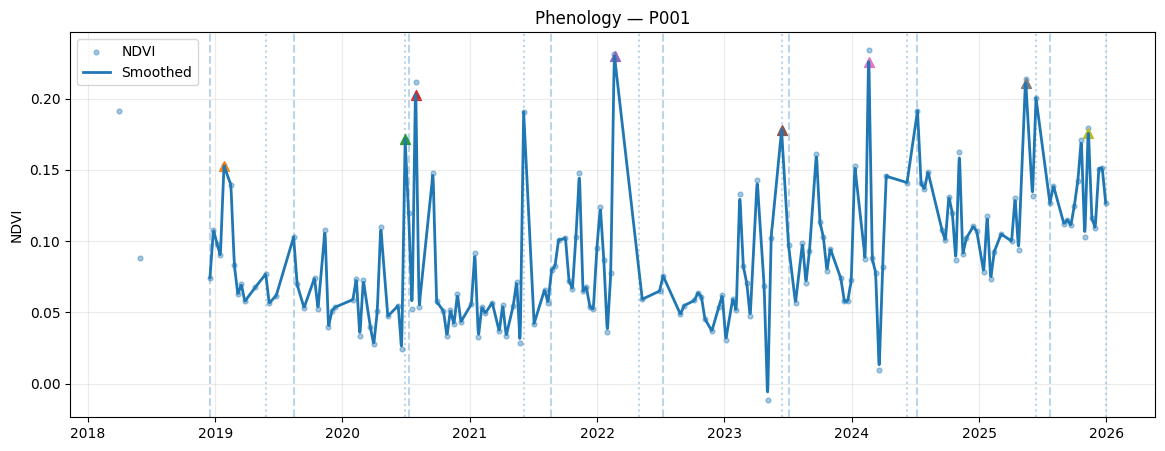

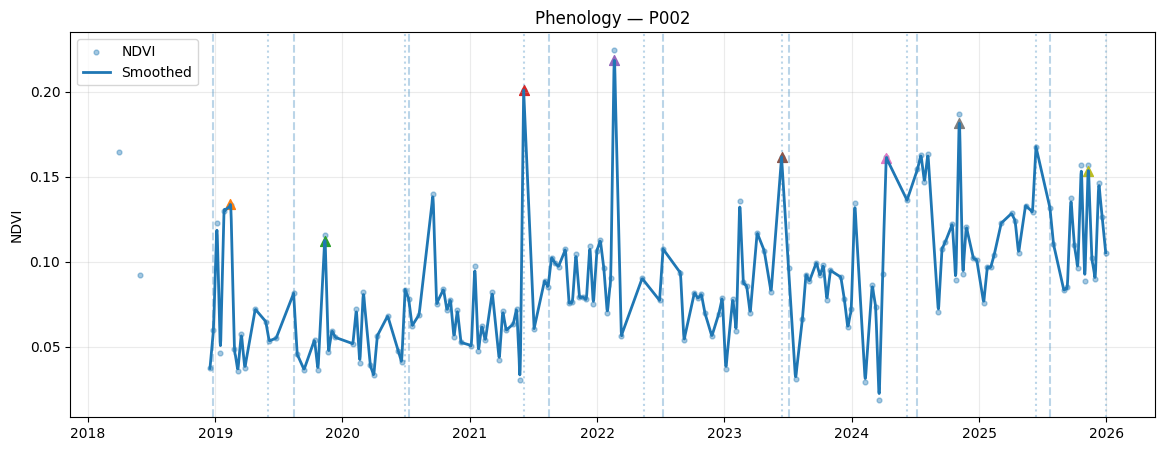

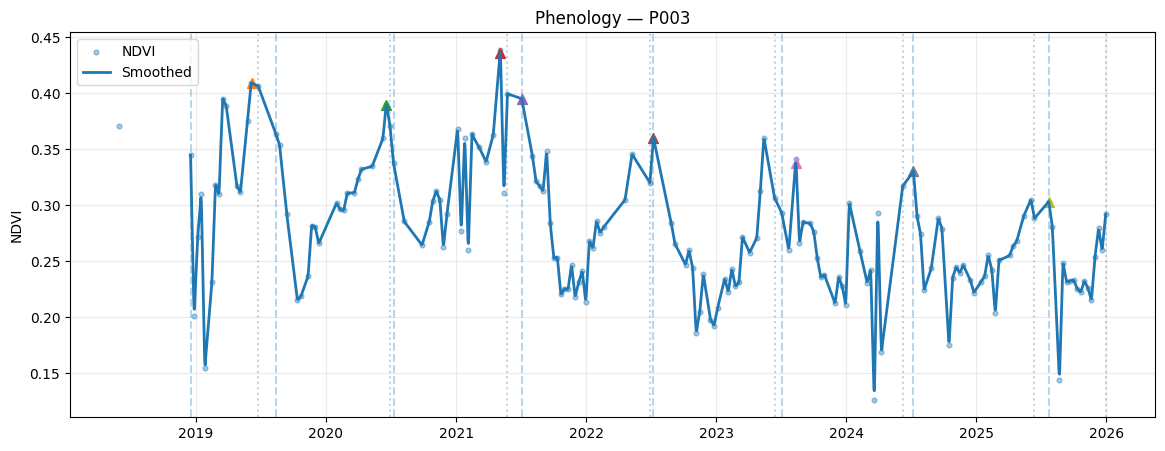

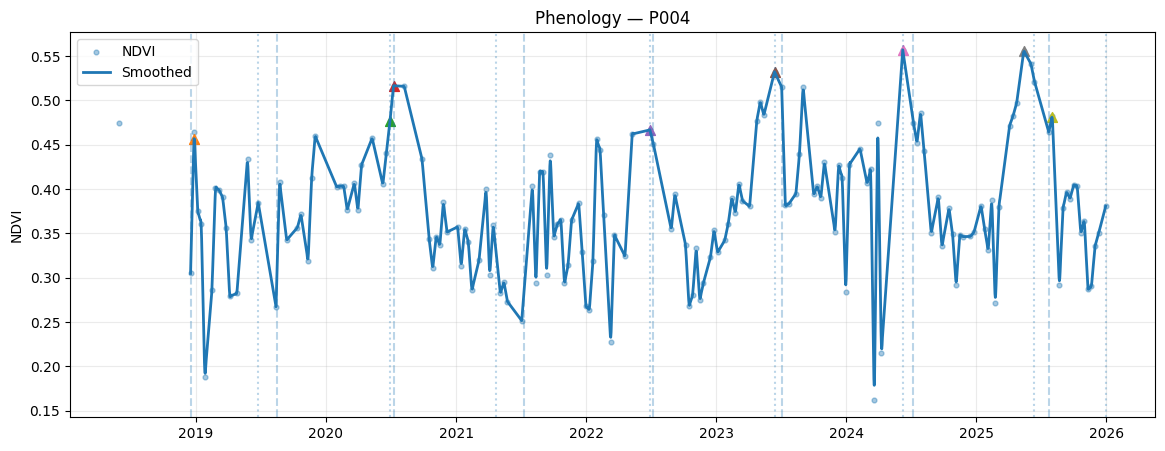

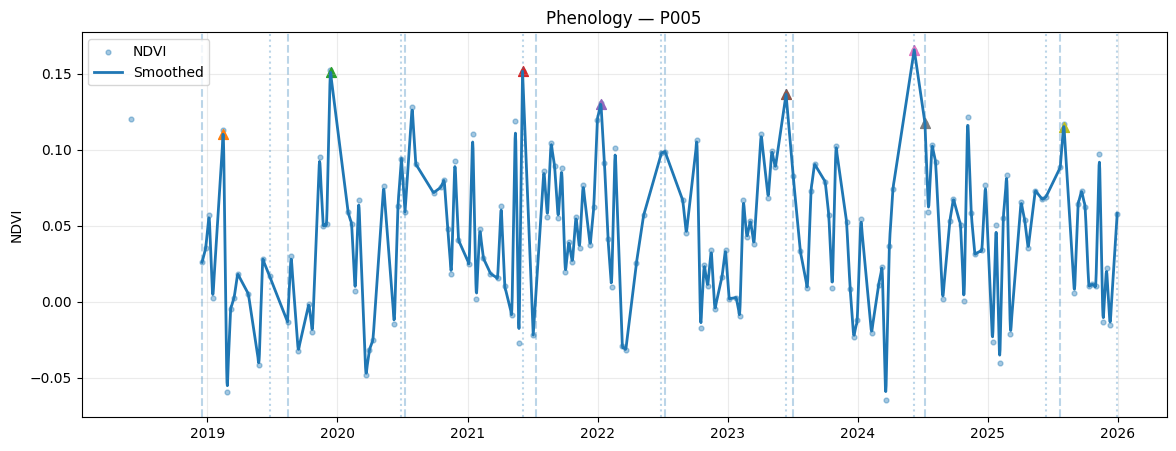

In [14]:
for site_id in vi_df["site_id"].unique()[:5]:
    obs = vi_df[vi_df.site_id == site_id]
    sm = smooth_df[smooth_df.site_id == site_id]
    met = phenology_df[phenology_df.site_id == site_id]

    plt.figure(figsize=(14,5))
    plt.scatter(obs.date,obs.NDVI,s=12,alpha=.4,label="NDVI")
    plt.plot(sm.date,sm.NDVI_smooth,lw=2,label="Smoothed")

    for _,r in met.iterrows():
        if pd.notna(r.SOS): plt.axvline(r.SOS,ls="--",alpha=.3)
        if pd.notna(r.Peak): plt.scatter(r.Peak,r.NDVI_peak,marker="^",s=50)
        if pd.notna(r.EOS): plt.axvline(r.EOS,ls=":",alpha=.3)

    plt.title(f"Phenology — {site_id}")
    plt.ylabel("NDVI")
    plt.grid(alpha=.25)
    plt.legend()
    plt.show()

## 10. ERA5-Land daily climate by site

In [15]:
import time

era5 = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
         .filterBounds(study_geometry)
         .filterDate(CLIM_BASELINE_START,ee.Date(END_DATE).advance(1,"day"))
         .select([
             "temperature_2m",
             "temperature_2m_min",
             "temperature_2m_max",
             "total_precipitation_sum"
         ]))

def sample_era5_site(site, pause_seconds=0.2, chunk_freq="YS"):
    point = ee.Geometry.Point([float(site["longitude"]), float(site["latitude"])])
    parts = []

    for d0, d1 in date_chunks(CLIM_BASELINE_START, END_DATE, freq=chunk_freq):
        collection = era5.filterBounds(point).filterDate(
            d0.strftime("%Y-%m-%d"),
            d1.strftime("%Y-%m-%d")
        )
        df = collection_region_df(collection, point, ERA5_SCALE_M)
        if not df.empty:
            parts.append(df)

        if pause_seconds:
            time.sleep(pause_seconds)

    if not parts:
        return pd.DataFrame()

    df = pd.concat(parts, ignore_index=True)
    df = df.rename(columns={
        "time": "time_ms",
        "temperature_2m": "Tmean_K",
        "temperature_2m_min": "Tmin_K",
        "temperature_2m_max": "Tmax_K",
        "total_precipitation_sum": "P_m"
    })
    df["site_id"] = site["site_id"]
    df["date"] = pd.to_datetime(df["time_ms"], unit="ms")

    return df[["site_id", "date", "Tmean_K", "Tmin_K", "Tmax_K", "P_m"]]

print("ERA5-Land daily images:", era5.size().getInfo())
print("ERA5 sampling will run site by site in the next cell.")

ERA5-Land daily images: 9497
ERA5 sampling will run site by site in the next cell.


In [ ]:
site_records = gdf[["site_id", "longitude", "latitude"]].to_dict("records")

climate_parts = []
for site in site_records:
    part = sample_era5_site(site)
    print(f"{site['site_id']}: {len(part)} ERA5 daily samples")
    if not part.empty:
        climate_parts.append(part)

clim_df = pd.concat(climate_parts, ignore_index=True) if climate_parts else pd.DataFrame()
if clim_df.empty:
    raise ValueError("No valid ERA5-Land samples were returned.")

clim_df["date"] = pd.to_datetime(clim_df["date"])

for c in ["Tmean_K","Tmin_K","Tmax_K","P_m"]:
    clim_df[c] = pd.to_numeric(clim_df[c],errors="coerce")

clim_df["Tmean_C"] = clim_df.Tmean_K-273.15
clim_df["Tmin_C"] = clim_df.Tmin_K-273.15
clim_df["Tmax_C"] = clim_df.Tmax_K-273.15
clim_df["P_mm"] = (clim_df.P_m*1000).clip(lower=0)

clim_df["doy"] = clim_df.date.dt.dayofyear
clim_df["month"] = clim_df.date.dt.month
clim_df["pheno_year"] = assign_pheno_year(
    clim_df.date, PHENO_YEAR_START_MONTH
)

clim_df = clim_df.sort_values(["site_id","date"]).reset_index(drop=True)
display(clim_df.head())

P001: 9497 ERA5 daily samples
P002: 9497 ERA5 daily samples
P003: 9497 ERA5 daily samples


P004: 9497 ERA5 daily samples
P005: 9497 ERA5 daily samples
P006: 9497 ERA5 daily samples
P007: 9497 ERA5 daily samples
P008: 9497 ERA5 daily samples
P009: 9497 ERA5 daily samples
P010: 9497 ERA5 daily samples
P011: 9497 ERA5 daily samples
P012: 9497 ERA5 daily samples
P013: 9497 ERA5 daily samples
P014: 9497 ERA5 daily samples
P015: 9497 ERA5 daily samples
P016: 9497 ERA5 daily samples
P017: 9497 ERA5 daily samples
P018: 9497 ERA5 daily samples
P019: 9497 ERA5 daily samples
P020: 9497 ERA5 daily samples
P021: 9497 ERA5 daily samples
P022: 9497 ERA5 daily samples
P023: 9497 ERA5 daily samples
P024: 9497 ERA5 daily samples
P025: 9497 ERA5 daily samples
P026: 9497 ERA5 daily samples
P027: 9497 ERA5 daily samples
P028: 9497 ERA5 daily samples
P029: 9497 ERA5 daily samples
P030: 9497 ERA5 daily samples
P031: 9497 ERA5 daily samples
P032: 9497 ERA5 daily samples


P033: 9497 ERA5 daily samples
P034: 9497 ERA5 daily samples
P035: 9497 ERA5 daily samples
P036: 9497 ERA5 daily samples
P037: 9497 ERA5 daily samples
P038: 9497 ERA5 daily samples
P039: 9497 ERA5 daily samples
P040: 9497 ERA5 daily samples
P041: 9497 ERA5 daily samples
P042: 9497 ERA5 daily samples
P043: 9497 ERA5 daily samples
P044: 9497 ERA5 daily samples
P045: 9497 ERA5 daily samples
P046: 9497 ERA5 daily samples
P047: 9497 ERA5 daily samples
P048: 9497 ERA5 daily samples
P049: 9497 ERA5 daily samples
P050: 9497 ERA5 daily samples
P051: 9497 ERA5 daily samples
P052: 9497 ERA5 daily samples
P053: 9497 ERA5 daily samples
P054: 9497 ERA5 daily samples
P055: 9497 ERA5 daily samples


P056: 9497 ERA5 daily samples
P057: 9497 ERA5 daily samples
P058: 9497 ERA5 daily samples
P059: 9497 ERA5 daily samples
P060: 9497 ERA5 daily samples
P061: 9497 ERA5 daily samples
P062: 9497 ERA5 daily samples
P063: 9497 ERA5 daily samples
P064: 9497 ERA5 daily samples
P065: 9497 ERA5 daily samples
P066: 9497 ERA5 daily samples
P067: 9497 ERA5 daily samples
P068: 9497 ERA5 daily samples
P069: 9497 ERA5 daily samples
P070: 9497 ERA5 daily samples
P071: 9497 ERA5 daily samples
P072: 9497 ERA5 daily samples
P073: 9497 ERA5 daily samples
P074: 9497 ERA5 daily samples
P075: 9497 ERA5 daily samples
P076: 9497 ERA5 daily samples
P077: 9497 ERA5 daily samples
P078: 9497 ERA5 daily samples
P079: 9497 ERA5 daily samples


## 11. Climate extremes by site

In [ ]:
parts = []

for site_id,sdf in clim_df.groupby("site_id"):
    sdf = sdf.sort_values("date").copy()

    base = sdf[
        (sdf.date >= pd.Timestamp(CLIM_BASELINE_START)) &
        (sdf.date <= pd.Timestamp(CLIM_BASELINE_END))
    ].copy()

    if base.empty:
        continue

    tq = base.groupby("doy").Tmax_C.quantile(HEAT_PERCENTILE/100)
    pq = base.groupby("doy").P_mm.quantile(HEAVY_RAIN_PERCENTILE/100)

    sdf["Tmax_q"] = sdf.doy.map(tq)
    sdf["P_q"] = sdf.doy.map(pq)

    sdf["extreme_heat"] = sdf.Tmax_C > sdf.Tmax_q
    sdf["heavy_rain"] = sdf.P_mm > sdf.P_q

    sdf["P_roll_mm"] = (
        sdf.set_index("date").P_mm
        .rolling(f"{ROLLING_RAIN_DAYS}D",
                 min_periods=max(10,ROLLING_RAIN_DAYS//2))
        .sum().values
    )

    b = sdf[
        (sdf.date >= pd.Timestamp(CLIM_BASELINE_START)) &
        (sdf.date <= pd.Timestamp(CLIM_BASELINE_END))
    ]

    stats = b.groupby("month").P_roll_mm.agg(["mean","std"])
    sdf = sdf.join(stats,on="month",rsuffix="_base")

    sdf["P30_z"] = (sdf.P_roll_mm-sdf["mean"])/sdf["std"].replace(0,np.nan)
    sdf["dry_extreme"] = sdf.P30_z <= DRY_Z_THRESHOLD

    parts.append(sdf)

clim_ext_df = pd.concat(parts,ignore_index=True)

analysis_clim = clim_ext_df[
    (clim_ext_df.date >= pd.Timestamp(START_DATE)) &
    (clim_ext_df.date <= pd.Timestamp(END_DATE))
].copy()

display(analysis_clim.head())

## 12. Site × year climate summary and phenology merge

In [ ]:
season_climate = (
    analysis_clim
    .groupby(["site_id","pheno_year"])
    .agg(
        mean_T_C=("Tmean_C","mean"),
        max_T_C=("Tmax_C","max"),
        total_P_mm=("P_mm","sum"),
        heat_days=("extreme_heat","sum"),
        heavy_rain_days=("heavy_rain","sum"),
        dry_extreme_days=("dry_extreme","sum"),
        min_P30_z=("P30_z","min")
    )
    .reset_index()
)

season_climate["pheno_year"] = season_climate.pheno_year.astype(int)

combined_df = phenology_df.merge(
    season_climate,
    on=["site_id","pheno_year"],
    how="left"
)

display(combined_df.head(30))

## 13. Event-centred NDVI response

In [ ]:
EVENT_DATE = "2022-02-05"
EVENT_NAME = "Example extreme event"
PRE_EVENT_DAYS = 90

event_date = pd.Timestamp(EVENT_DATE)
event_rows = []

for site_id,sdf in vi_df.groupby("site_id"):
    pre = sdf[
        (sdf.date >= event_date-pd.Timedelta(days=PRE_EVENT_DAYS)) &
        (sdf.date < event_date)
    ].NDVI.dropna()

    post30 = sdf[
        (sdf.date >= event_date) &
        (sdf.date <= event_date+pd.Timedelta(days=30))
    ].NDVI.dropna()

    post90 = sdf[
        (sdf.date >= event_date) &
        (sdf.date <= event_date+pd.Timedelta(days=90))
    ].NDVI.dropna()

    event_rows.append({
        "site_id":site_id,
        "event_date":event_date,
        "pre_NDVI":pre.mean(),
        "post30_NDVI":post30.mean(),
        "post90_NDVI":post90.mean(),
        "delta30":post30.mean()-pre.mean(),
        "delta90":post90.mean()-pre.mean()
    })

event_summary_df = pd.DataFrame(event_rows)
display(event_summary_df)

## 14. Export CSV results

In [ ]:
gdf.drop(columns="geometry").to_csv("sites_from_geopackage.csv",index=False)
vi_df.to_csv("sentinel2_timeseries_by_site.csv",index=False)
phenology_df.to_csv("phenology_metrics_by_site.csv",index=False)
analysis_clim.to_csv("climate_extremes_by_site.csv",index=False)
season_climate.to_csv("climate_summary_by_site_year.csv",index=False)
combined_df.to_csv("phenology_climate_by_site_year.csv",index=False)
event_summary_df.to_csv("event_response_by_site.csv",index=False)

print("Exports completed.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path to save files in Google Drive
drive_path = '/content/drive/My Drive/Colab Notebooks/'

# Export the CSV files to Google Drive
gdf.drop(columns='geometry').to_csv(drive_path + "sites_from_geopackage.csv", index=False)
vi_df.to_csv(drive_path + "sentinel2_timeseries_by_site.csv", index=False)
phenology_df.to_csv(drive_path + "phenology_metrics_by_site.csv", index=False)
analysis_clim.to_csv(drive_path + "climate_extremes_by_site.csv", index=False)
season_climate.to_csv(drive_path + "climate_summary_by_site_year.csv", index=False)
combined_df.to_csv(drive_path + "phenology_climate_by_site_year.csv", index=False)
event_summary_df.to_csv(drive_path + "event_response_by_site.csv", index=False)

print(f"All CSVs exported to {drive_path}")

## Scaling note

This version samples Sentinel-2 and ERA5-Land site by site before doing tabular aggregation in pandas. For hundreds or thousands of sites, process sites in batches or export per-site tables to Drive/Cloud Storage.
